# AI Linear Algebra · Reaction ODEs · Polymer Chemistry · Intramolecular Reactions

| § | Topic | Key result |
|---|---|---|
|1| AI linear algebra | SVD $A=U\Sigma V^T$; PCA; low-rank error $\sigma_{k+1}$ (Eckart-Young) |
|2| Reaction kinetics | $d[\text{A}]/dt=-k[\text{A}][\text{B}]$; Arrhenius $k=Ae^{-E_a/RT}$; stiff VODE |
|3| Polymer chemistry | Flory MW distribution; $\bar{M}_n, \bar{M}_w, \text{PDI}$; PE/PP/PET |
|4| Intramolecular | Jacobson-Stockmayer: $K_c\propto n^{-3/2}$ chain length; ring vs linear |


## §1 AI Linear Algebra — SVD, PCA, Low-Rank

**SVD**: every matrix $A\in\mathbb{R}^{m\times n}$ factors as $A=U\Sigma V^T$.
- $U$: left singular vectors (eigenvectors of $AA^T$)
- $V$: right singular vectors (eigenvectors of $A^TA$)
- $\sigma_i$: singular values, square roots of eigenvalues

**Eckart-Young theorem**: best rank-$k$ approximation is $A_k=\sum_{i=1}^k\sigma_i u_i v_i^T$, error $\|A-A_k\|_2=\sigma_{k+1}$.

**PCA**: center data $X$, compute SVD of $X/\sqrt{n-1}$ → principal components = columns of $V$, variance explained = $\sigma_i^2$.

**Connection to AI**: weight matrix $W\in\mathbb{R}^{d_{out}\times d_{in}}$ — LoRA (Low-Rank Adaptation) replaces $\Delta W = AB$ where $A\in\mathbb{R}^{d\times r}$, $B\in\mathbb{R}^{r\times d}$, $r\ll d$.


SVD decomposition:
  A shape: (120, 80)   rank(A_clean)=5
  Top 10 singular values: [57.03 36.84 28.9  28.82 27.46 27.13 26.57 26.36 25.8  25.04]
  Spectral gap at k=5: σ_5=27.46 >> σ_6=27.13
  rank- 1: ||A-Ak||_2 = 36.841  (σ_2=36.841)  compression=98%
  rank- 3: ||A-Ak||_2 = 28.823  (σ_4=28.823)  compression=94%
  rank- 5: ||A-Ak||_2 = 27.126  (σ_6=27.126)  compression=90%
  rank-10: ||A-Ak||_2 = 24.621  (σ_11=24.621)  compression=79%
  rank-20: ||A-Ak||_2 = 21.063  (σ_21=21.063)  compression=58%

PCA on 300×20 data:
  Variance explained by PC1: 9.0%
  Variance explained by PC1+PC2: 15.3%
  To explain 90%: need 1 components

LoRA compression (d=256, r=8):
  Full params: 65,536
  LoRA params: 4,096  (6.2% of full)
  Relative approximation error: 0.9417


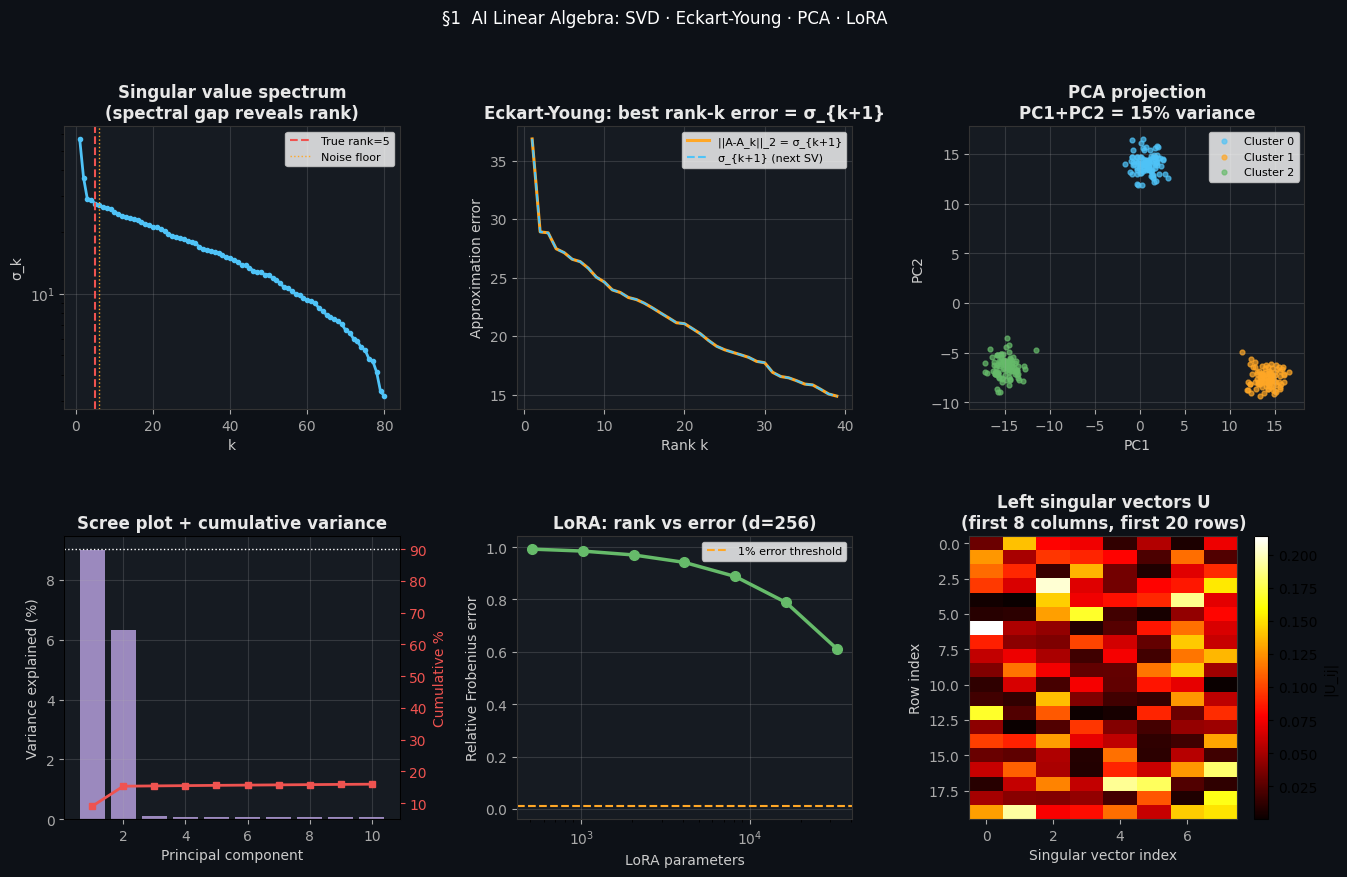

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.integrate import solve_ivp
from scipy.stats import chi2
import warnings; warnings.filterwarnings('ignore')

rng = np.random.default_rng(42)

# ── SVD on a synthetic data matrix ────────────────────────────────────────────
m, n = 120, 80
true_rank = 5
# Low-rank signal + noise
U_true = np.linalg.qr(rng.standard_normal((m, true_rank)))[0]
V_true = np.linalg.qr(rng.standard_normal((n, true_rank)))[0]
S_true = np.diag([50, 30, 15, 8, 4])
A_clean = U_true @ S_true @ V_true.T
noise   = rng.standard_normal((m, n)) * 1.5
A       = A_clean + noise

U, s, Vt = np.linalg.svd(A, full_matrices=False)
print("SVD decomposition:")
print(f"  A shape: {A.shape}   rank(A_clean)={true_rank}")
print(f"  Top 10 singular values: {np.round(s[:10], 2)}")
print(f"  Spectral gap at k={true_rank}: σ_{true_rank}={s[true_rank-1]:.2f} >> σ_{true_rank+1}={s[true_rank]:.2f}")

# Eckart-Young: low-rank approximation error
for k in [1, 3, 5, 10, 20]:
    Ak  = (U[:, :k] * s[:k]) @ Vt[:k, :]
    err = np.linalg.norm(A - Ak, ord=2)
    compression = 100*(1 - k*(m+n+1)/(m*n))
    print(f"  rank-{k:2d}: ||A-Ak||_2 = {err:.3f}  (σ_{k+1}={s[k]:.3f})  "
          f"compression={compression:.0f}%")

# ── PCA ────────────────────────────────────────────────────────────────────────
# Simulated dataset: 3 clusters in 20D
n_pts = 300; d = 20; n_clusters = 3
centers = rng.standard_normal((n_clusters, d)) * 4
X_list  = [centers[i] + rng.standard_normal((n_pts//n_clusters, d)) for i in range(n_clusters)]
X_data  = np.vstack(X_list)
labels  = np.repeat(np.arange(n_clusters), n_pts//n_clusters)

# PCA via SVD
X_c    = X_data - X_data.mean(axis=0)
Upca, spca, Vtpca = np.linalg.svd(X_c / np.sqrt(n_pts-1), full_matrices=False)
variance_ratio = spca**2 / spca.sum()**2 * 100
X_proj = X_c @ Vtpca[:2].T   # project to top-2 PCs

print(f"\nPCA on {n_pts}×{d} data:")
print(f"  Variance explained by PC1: {variance_ratio[0]:.1f}%")
print(f"  Variance explained by PC1+PC2: {sum(variance_ratio[:2]):.1f}%")
print(f"  To explain 90%: need {np.argmax(np.cumsum(variance_ratio)>90)+1} components")

# ── LoRA rank decomposition ────────────────────────────────────────────────────
d_model = 256; r_lora = 8
W_full  = rng.standard_normal((d_model, d_model)) * 0.01
# LoRA: approximate W_full ≈ A @ B  (rank r)
Ul, sl, Vtl = np.linalg.svd(W_full, full_matrices=False)
A_lora = Ul[:, :r_lora] * sl[:r_lora]
B_lora = Vtl[:r_lora, :]
W_approx = A_lora @ B_lora
err_lora = np.linalg.norm(W_full - W_approx, 'fro') / np.linalg.norm(W_full, 'fro')
params_full = d_model**2
params_lora = r_lora*(d_model + d_model)
print(f"\nLoRA compression (d={d_model}, r={r_lora}):")
print(f"  Full params: {params_full:,}")
print(f"  LoRA params: {params_lora:,}  ({params_lora/params_full*100:.1f}% of full)")
print(f"  Relative approximation error: {err_lora:.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 9), facecolor='#0d1117')
gs  = GridSpec(2, 3, fig, hspace=0.45, wspace=0.35)

ax = fig.add_subplot(gs[0,0]); ax.set_facecolor('#161b22')
ax.semilogy(range(1,len(s)+1), s, '#4fc3f7', lw=2, marker='o', ms=3)
ax.axvline(true_rank, color='#ef5350', ls='--', lw=1.5, label=f'True rank={true_rank}')
ax.axvline(true_rank+1, color='#ffa726', ls=':', lw=1, label='Noise floor')
ax.set_xlabel('k'); ax.set_ylabel('σ_k')
ax.set_title('Singular value spectrum\n(spectral gap reveals rank)',
             color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)
ax.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax.spines.values()]
ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')

ax = fig.add_subplot(gs[0,1]); ax.set_facecolor('#161b22')
k_vals = np.arange(1, min(40, len(s)))
errors = [np.linalg.norm(A-(U[:,:k]*s[:k])@Vt[:k,:],ord=2) for k in k_vals]
ax.plot(k_vals, errors, '#ffa726', lw=2.2, label='||A-A_k||_2 = σ_{k+1}')
ax.plot(k_vals, s[k_vals], '#4fc3f7', lw=1.5, ls='--', label='σ_{k+1} (next SV)')
ax.set_xlabel('Rank k'); ax.set_ylabel('Approximation error')
ax.set_title('Eckart-Young: best rank-k error = σ_{k+1}',
             color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)
ax.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax.spines.values()]
ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')

ax = fig.add_subplot(gs[0,2]); ax.set_facecolor('#161b22')
cols_c = ['#4fc3f7','#ffa726','#66bb6a']
for i in range(n_clusters):
    mask = labels==i
    ax.scatter(X_proj[mask,0], X_proj[mask,1], s=12, alpha=0.7, c=cols_c[i],
               label=f'Cluster {i}')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'PCA projection\nPC1+PC2 = {sum(variance_ratio[:2]):.0f}% variance',
             color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)
ax.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax.spines.values()]
ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')

ax = fig.add_subplot(gs[1,0]); ax.set_facecolor('#161b22')
ax.bar(range(1,11), variance_ratio[:10], color='#b39ddb', alpha=0.85)
cum = np.cumsum(variance_ratio)
ax2 = ax.twinx()
ax2.plot(range(1,11), cum[:10], '#ef5350', lw=2, marker='s', ms=5)
ax2.axhline(90, color='white', ls=':', lw=1)
ax2.set_ylabel('Cumulative %', color='#ef5350')
ax2.tick_params(colors='#ef5350')
ax.set_xlabel('Principal component'); ax.set_ylabel('Variance explained (%)')
ax.set_title('Scree plot + cumulative variance', color='#e8e8e8', fontweight='bold')
ax.grid(alpha=0.2)
ax.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax.spines.values()]
ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')

ax = fig.add_subplot(gs[1,1]); ax.set_facecolor('#161b22')
r_vals = [1,2,4,8,16,32,64]
params_r = [r*(d_model+d_model) for r in r_vals]
errors_r  = []
for r in r_vals:
    Wa = (Ul[:,:r]*sl[:r]) @ Vtl[:r,:]
    errors_r.append(np.linalg.norm(W_full-Wa,'fro')/np.linalg.norm(W_full,'fro'))
ax.semilogx(params_r, errors_r, '#66bb6a', lw=2.5, marker='o', ms=7)
ax.axhline(0.01, color='#ffa726', ls='--', lw=1.5, label='1% error threshold')
ax.set_xlabel('LoRA parameters'); ax.set_ylabel('Relative Frobenius error')
ax.set_title(f'LoRA: rank vs error (d={d_model})', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)
ax.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax.spines.values()]
ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')

ax = fig.add_subplot(gs[1,2]); ax.set_facecolor('#161b22')
im = ax.imshow(np.abs(U[:20,:8]), cmap='hot', aspect='auto')
plt.colorbar(im, ax=ax, label='|U_ij|')
ax.set_title('Left singular vectors U\n(first 8 columns, first 20 rows)',
             color='#e8e8e8', fontweight='bold')
ax.set_xlabel('Singular vector index'); ax.set_ylabel('Row index')
ax.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax.spines.values()]
ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')

plt.suptitle('§1  AI Linear Algebra: SVD · Eckart-Young · PCA · LoRA',
             color='white', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('/tmp/s1_linalg.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §2 Reaction Kinetics — ODEs, Arrhenius, Stiff Systems

**Rate law** for A + B → C:
$$\frac{d[\mathrm{A}]}{dt} = -k[\mathrm{A}][\mathrm{B}], \quad k(T) = A\,e^{-E_a/RT}$$

**Stiff ODE**: timescales span many orders of magnitude (fast equilibration + slow production). Example: Michaelis-Menten enzyme kinetics.

$$\frac{d[\mathrm{ES}]}{dt} = k_1[\mathrm{E}][\mathrm{S}] - (k_{-1}+k_2)[\mathrm{ES}]$$

**Polymer chain growth** (addition polymerization radical chain):
$$\frac{d[M]}{dt} = -k_p[M][P^\bullet], \quad \frac{d[P^\bullet]}{dt} = R_i - k_t[P^\bullet]^2$$


A + B -> C kinetics (k=0.1 L/mol/s):
  t=0:  [A]=1.000  [B]=1.500  [C]=0.000
  t=30: [A]=0.087  [B]=0.587  [C]=0.913
  t=60: [A]=0.017  [B]=0.517  [C]=0.983

Arrhenius k(T) at 298K and 373K:
  PE polymerisation        : k(25°C)=5.52e+04  k(100°C)=6.29e+05  ratio=11.4×
  Nylon hydrolysis         : k(25°C)=9.50e-05  k(100°C)=6.27e-02  ratio=660.0×
  PET transesterif.        : k(25°C)=3.04e-01  k(100°C)=3.96e+01  ratio=130.2×
  PP propagation           : k(25°C)=2.46e+04  k(100°C)=3.30e+05  ratio=13.4×

Michaelis-Menten (stiff Radau solver):
  Km = (k-1+k2)/k1 = 1.10e-03 M
  Vmax = k2*E0 = 1.00e-05 M/s
  ES peak: 4.76e-08 M at t=6.61 ms
  Stiffness ratio k1/k2 = 10000:1


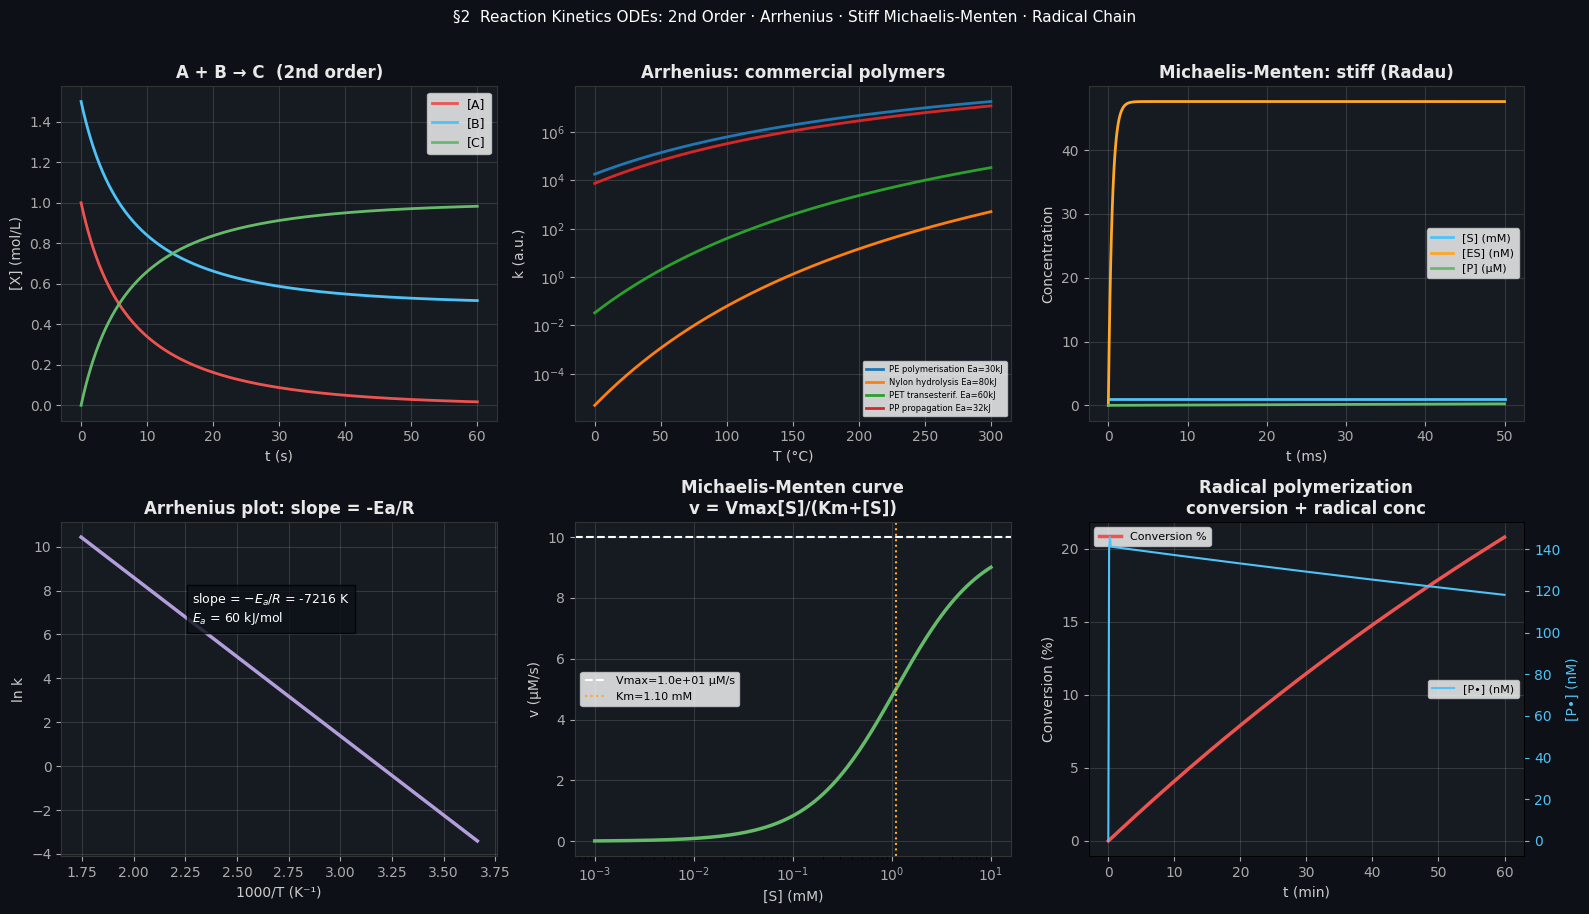

In [2]:
from scipy.integrate import solve_ivp
from scipy.constants import R as R_gas

# ── Simple 2nd-order: A + B → C ───────────────────────────────────────────────
def rxn_AB(t, y, k):
    A, B, C = y
    rate = k*A*B
    return [-rate, -rate, rate]

k_rxn  = 0.1   # L/mol/s
y0_AB  = [1.0, 1.5, 0.0]   # mol/L
t_span = (0, 60)
sol_AB = solve_ivp(rxn_AB, t_span, y0_AB, args=(k_rxn,),
                   dense_output=True, max_step=0.5)
t_plot = np.linspace(0, 60, 500)
y_AB   = sol_AB.sol(t_plot)

print("A + B -> C kinetics (k=0.1 L/mol/s):")
print(f"  t=0:  [A]={y_AB[0,0]:.3f}  [B]={y_AB[1,0]:.3f}  [C]={y_AB[2,0]:.3f}")
print(f"  t=30: [A]={y_AB[0,250]:.3f}  [B]={y_AB[1,250]:.3f}  [C]={y_AB[2,250]:.3f}")
print(f"  t=60: [A]={y_AB[0,-1]:.3f}  [B]={y_AB[1,-1]:.3f}  [C]={y_AB[2,-1]:.3f}")

# ── Arrhenius temperature dependence ──────────────────────────────────────────
Ea_vals = {'PE polymerisation': 30e3,   # J/mol
           'Nylon hydrolysis':  80e3,
           'PET transesterif.': 60e3,
           'PP propagation':    32e3}
A_pre   = 1e10   # pre-exponential factor (1/s or L/mol/s)
T_K     = np.linspace(273, 573, 300)

print("\nArrhenius k(T) at 298K and 373K:")
for name, Ea in Ea_vals.items():
    k298 = A_pre * np.exp(-Ea/(R_gas*298))
    k373 = A_pre * np.exp(-Ea/(R_gas*373))
    print(f"  {name:25}: k(25°C)={k298:.2e}  k(100°C)={k373:.2e}  "
          f"ratio={k373/k298:.1f}×")

# ── Michaelis-Menten enzyme kinetics (stiff) ──────────────────────────────────
# E + S <-k1/k_1-> ES -k2-> E + P
k1, km1, k2 = 1e6, 1e3, 1e2   # 1/M/s, 1/s, 1/s  (stiff: k1 >> k2)
E0, S0       = 1e-7, 1e-3   # mol/L

def mm_ode(t, y):
    E, S, ES, P = y
    r_f = k1*E*S; r_r = km1*ES; r_cat = k2*ES
    dE  = -r_f + r_r + r_cat
    dS  = -r_f + r_r
    dES =  r_f - r_r - r_cat
    dP  = r_cat
    return [dE, dS, dES, dP]

y0_mm   = [E0, S0, 0.0, 0.0]
t_mm    = (0, 0.05)
sol_mm  = solve_ivp(mm_ode, t_mm, y0_mm, method='Radau',   # stiff solver
                    dense_output=True, rtol=1e-8, atol=1e-12)
t_mm_plot = np.linspace(0, 0.05, 1000)
y_mm      = sol_mm.sol(t_mm_plot)

Km_theory = (km1+k2)/k1
vmax      = k2*E0
print(f"\nMichaelis-Menten (stiff Radau solver):")
print(f"  Km = (k-1+k2)/k1 = {Km_theory:.2e} M")
print(f"  Vmax = k2*E0 = {vmax:.2e} M/s")
print(f"  ES peak: {y_mm[2].max():.2e} M at t={t_mm_plot[y_mm[2].argmax()]*1e3:.2f} ms")
print(f"  Stiffness ratio k1/k2 = {k1/k2:.0f}:1")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(2, 3, figsize=(16, 9), facecolor='#0d1117')
for ax in axes2.flat: ax.set_facecolor('#161b22')

ax = axes2[0,0]
ax.plot(t_plot, y_AB[0], '#ef5350', lw=2, label='[A]')
ax.plot(t_plot, y_AB[1], '#4fc3f7', lw=2, label='[B]')
ax.plot(t_plot, y_AB[2], '#66bb6a', lw=2, label='[C]')
ax.set_xlabel('t (s)'); ax.set_ylabel('[X] (mol/L)')
ax.set_title('A + B → C  (2nd order)', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.2)

ax = axes2[0,1]
for name, Ea in Ea_vals.items():
    k_T = A_pre * np.exp(-Ea/(R_gas*T_K))
    ax.semilogy(T_K-273, k_T, lw=2, label=f'{name} Ea={Ea/1e3:.0f}kJ')
ax.set_xlabel('T (°C)'); ax.set_ylabel('k (a.u.)')
ax.set_title('Arrhenius: commercial polymers', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=6); ax.grid(alpha=0.2, which='both')

ax = axes2[0,2]
ax.plot(t_mm_plot*1e3, y_mm[1]*1e3, '#4fc3f7', lw=2, label='[S] (mM)')
ax.plot(t_mm_plot*1e3, y_mm[2]*1e9, '#ffa726', lw=2, label='[ES] (nM)')
ax.plot(t_mm_plot*1e3, y_mm[3]*1e6, '#66bb6a', lw=2, label='[P] (µM)')
ax.set_xlabel('t (ms)'); ax.set_ylabel('Concentration')
ax.set_title('Michaelis-Menten: stiff (Radau)', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

# Activation energy from Arrhenius plot (ln k vs 1/T)
ax = axes2[1,0]
Ea_demo = 60e3
k_arr   = A_pre * np.exp(-Ea_demo/(R_gas*T_K))
ax.plot(1000/T_K, np.log(k_arr), '#b39ddb', lw=2.5)
slope = -Ea_demo/R_gas
ax.text(0.3, 0.7, f'slope = $-E_a/R$ = {slope:.0f} K\n$E_a$ = {Ea_demo/1e3:.0f} kJ/mol',
        transform=ax.transAxes, color='white', fontsize=9,
        bbox=dict(facecolor='#0d1117', alpha=0.8))
ax.set_xlabel('1000/T (K⁻¹)'); ax.set_ylabel('ln k')
ax.set_title('Arrhenius plot: slope = -Ea/R', color='#e8e8e8', fontweight='bold')
ax.grid(alpha=0.2)

# v vs [S] Michaelis-Menten curve
ax = axes2[1,1]
S_range = np.logspace(-6, -2, 200)   # M
v_MM    = vmax * S_range / (Km_theory + S_range)
ax.semilogx(S_range*1e3, v_MM*1e6, '#66bb6a', lw=2.5)
ax.axhline(vmax*1e6, color='white', ls='--', lw=1.5, label=f'Vmax={vmax*1e6:.1e} µM/s')
ax.axvline(Km_theory*1e3, color='#ffa726', ls=':', lw=1.5, label=f'Km={Km_theory*1e3:.2f} mM')
ax.set_xlabel('[S] (mM)'); ax.set_ylabel('v (µM/s)')
ax.set_title('Michaelis-Menten curve\nv = Vmax[S]/(Km+[S])', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

# Radical polymerization ODE
ax = axes2[1,2]
ki, kp_rad, kt_rad = 1e-4, 500, 1e8   # initiation, propagation, termination
M0_rad, I0 = 8.0, 0.01   # mol/L
def rad_poly(t, y):
    M, P, Mn_chain = y
    Ri   = 2*ki*I0*np.exp(-ki*t)   # first-order initiator decomp
    dP   = Ri - kt_rad*P**2
    dM   = -kp_rad*M*P
    dMn  = kp_rad*M if P > 0 else 0   # chain growth rate (proxy)
    return [dM, max(dP, -P/1e-9), dMn]
sol_rad = solve_ivp(rad_poly, (0, 3600), [M0_rad, 0.0, 0.0],
                    method='Radau', dense_output=True, max_step=10)
t_rad = np.linspace(0, 3600, 500)
y_rad = sol_rad.sol(t_rad)
conv  = (M0_rad - y_rad[0]) / M0_rad * 100
ax.plot(t_rad/60, conv, '#ef5350', lw=2.5, label='Conversion %')
ax2r = ax.twinx()
ax2r.plot(t_rad/60, y_rad[1]*1e9, '#4fc3f7', lw=1.5, label='[P•] (nM)')
ax2r.set_ylabel('[P•] (nM)', color='#4fc3f7')
ax2r.tick_params(colors='#4fc3f7')
ax.set_xlabel('t (min)'); ax.set_ylabel('Conversion (%)')
ax.set_title('Radical polymerization\nconversion + radical conc', color='#e8e8e8', fontweight='bold')
ax.legend(loc='upper left', fontsize=8); ax2r.legend(loc='center right', fontsize=8)
ax.grid(alpha=0.2)

for ax in axes2.flat:
    ax.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax.spines.values()]
    try: ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')
    except: pass

plt.suptitle('§2  Reaction Kinetics ODEs: 2nd Order · Arrhenius · Stiff Michaelis-Menten · Radical Chain',
             color='white', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('/tmp/s2_kinetics.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §3 Polymer Chemistry — Commercial Plastics & MW Distribution

**Flory most-probable distribution** (step-growth, e.g. nylon, PET):
$$P(n) = p^{n-1}(1-p), \quad \bar{M}_n = M_0/(1-p), \quad \text{PDI} = \bar{M}_w/\bar{M}_n \to 2$$

**Addition polymerization** (PE, PP): $\bar{M}_n = k_p[M]/\sqrt{k_t[I]}$ — kinetic chain length.

**Commercial plastics**:
| Polymer | Process | $T_m$ | PDI | Application |
|---|---|---|---|---|
| HDPE | Ziegler-Natta | 135°C | 3-8 | bottles, pipes |
| iPP | metallocene | 165°C | 2-4 | packaging, fibers |
| PET | condensation | 260°C | 1.8-2.1 | bottles, textiles |
| Nylon-6,6 | condensation | 265°C | 1.8-2.0 | engineering parts |


Flory distribution for step-growth polymerization:
     p    Mn (g/mol)    Mw (g/mol)     PDI        Xn
 0.900          1000          1900   1.900        10
 0.950          2000          3900   1.950        20
 0.990         10000         19900   1.990       100
 0.999        100000        199900   1.999      1000

Verification p=0.99:
  Mn from distribution: 9995  (theory: 10000)
  Mw from distribution: 19857  (theory: 19900)
  PDI = 1.9866  (theory → 2 at high p)

Living polymerization (Poisson, DP=200):
  Mn = 20000  Mw = 20100  PDI = 1.0050
  Theory PDI = 1 + 1/DP = 1.0050


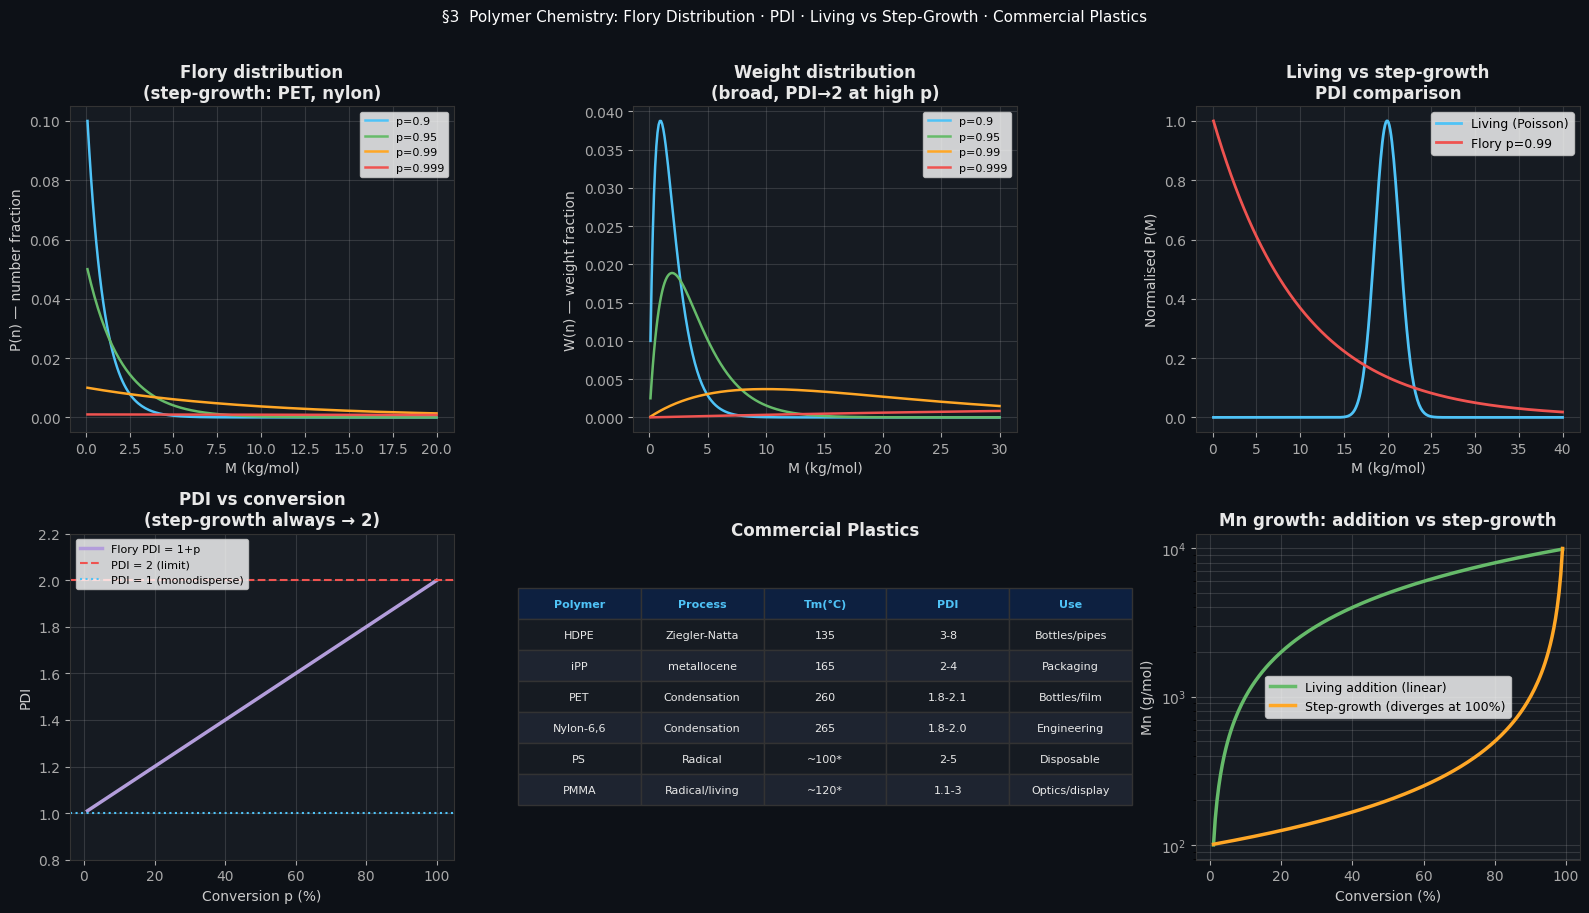

In [3]:
# ── Flory distribution (step-growth) ─────────────────────────────────────────
n_chain = np.arange(1, 1001)
M0_unit = 100.0   # monomer MW in g/mol (e.g. ethylene = 28, generic = 100)

p_conversions = [0.90, 0.95, 0.99, 0.999]
print("Flory distribution for step-growth polymerization:")
print(f"{'p':>6}  {'Mn (g/mol)':>12}  {'Mw (g/mol)':>12}  {'PDI':>6}  {'Xn':>8}")
for p in p_conversions:
    P_n  = (p**(n_chain-1)) * (1-p)
    Mn   = M0_unit / (1-p)
    Mw   = M0_unit * (1+p) / (1-p)
    PDI  = Mw / Mn
    Xn   = 1/(1-p)
    print(f"{p:>6.3f}  {Mn:>12.0f}  {Mw:>12.0f}  {PDI:>6.3f}  {Xn:>8.0f}")

# Number-average and weight-average from distribution
p_demo = 0.99
P_demo = (p_demo**(n_chain-1)) * (1-p_demo)
M_n_arr= n_chain * M0_unit
Mn_calc= np.sum(P_demo * M_n_arr)
Mw_calc= np.sum(P_demo * M_n_arr**2) / np.sum(P_demo * M_n_arr)
PDI_calc= Mw_calc / Mn_calc
print(f"\nVerification p=0.99:")
print(f"  Mn from distribution: {Mn_calc:.0f}  (theory: {M0_unit/(1-p_demo):.0f})")
print(f"  Mw from distribution: {Mw_calc:.0f}  (theory: {M0_unit*(1+p_demo)/(1-p_demo):.0f})")
print(f"  PDI = {PDI_calc:.4f}  (theory → 2 at high p)")

# ── Addition polymerization (living radical, narrow PDI) ─────────────────────
# Poisson distribution approximation for living polymerization
mu_dp = 200.0   # target DP
dp_range = np.arange(1, 401)
from scipy.stats import poisson
P_living = poisson.pmf(dp_range, mu_dp)
M_living = dp_range * M0_unit
Mn_liv = np.sum(P_living * M_living)
Mw_liv = np.sum(P_living * M_living**2) / np.sum(P_living * M_living)
PDI_liv= Mw_liv / Mn_liv
print(f"\nLiving polymerization (Poisson, DP={mu_dp:.0f}):")
print(f"  Mn = {Mn_liv:.0f}  Mw = {Mw_liv:.0f}  PDI = {PDI_liv:.4f}")
print(f"  Theory PDI = 1 + 1/DP = {1 + 1/mu_dp:.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig3, axes3 = plt.subplots(2, 3, figsize=(16, 9), facecolor='#0d1117')
for ax in axes3.flat: ax.set_facecolor('#161b22')

cols_p = ['#4fc3f7','#66bb6a','#ffa726','#ef5350']
ax = axes3[0,0]
for p, col in zip(p_conversions, cols_p):
    Pn = (p**(n_chain-1))*(1-p)
    ax.plot(n_chain[:200]*M0_unit/1000, Pn[:200],
            color=col, lw=1.8, label=f'p={p}')
ax.set_xlabel('M (kg/mol)'); ax.set_ylabel('P(n) — number fraction')
ax.set_title('Flory distribution\n(step-growth: PET, nylon)', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

ax = axes3[0,1]
for p, col in zip(p_conversions, cols_p):
    Pn  = (p**(n_chain-1))*(1-p)
    Wn  = n_chain*Pn / np.sum(n_chain*Pn)   # weight fraction
    ax.plot(n_chain[:300]*M0_unit/1000, Wn[:300],
            color=col, lw=1.8, label=f'p={p}')
ax.set_xlabel('M (kg/mol)'); ax.set_ylabel('W(n) — weight fraction')
ax.set_title('Weight distribution\n(broad, PDI→2 at high p)', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

ax = axes3[0,2]
Pn_demo = (p_demo**(n_chain-1))*(1-p_demo)
Wn_demo = n_chain*Pn_demo/np.sum(n_chain*Pn_demo)
ax.plot(dp_range*M0_unit/1000, P_living/P_living.max(), '#4fc3f7', lw=2, label='Living (Poisson)')
ax.plot(n_chain[:400]*M0_unit/1000, Pn_demo[:400]/Pn_demo.max(), '#ef5350', lw=2, label='Flory p=0.99')
ax.set_xlabel('M (kg/mol)'); ax.set_ylabel('Normalised P(M)')
ax.set_title('Living vs step-growth\nPDI comparison', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.2)

# PDI vs conversion
ax = axes3[1,0]
p_range = np.linspace(0.01, 0.999, 300)
PDI_range = (1+p_range)/(1-p_range) * (1-p_range)   # simplifies to (1+p)
PDI_range2 = (1+p_range)  # correct Flory PDI = (1+p)
ax.plot(p_range*100, PDI_range2, '#b39ddb', lw=2.5, label='Flory PDI = 1+p')
ax.axhline(2.0, color='#ef5350', ls='--', lw=1.5, label='PDI = 2 (limit)')
ax.axhline(1.0, color='#4fc3f7', ls=':', lw=1.5, label='PDI = 1 (monodisperse)')
ax.set_xlabel('Conversion p (%)'); ax.set_ylabel('PDI')
ax.set_title('PDI vs conversion\n(step-growth always → 2)', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)
ax.set_ylim(0.8, 2.2)

# Plastic properties comparison
ax = axes3[1,1]; ax.set_facecolor('#0d1117'); ax.axis('off')
plastics = [
    ['Polymer',  'Process',       'Tm(°C)', 'PDI',    'Use'],
    ['HDPE',     'Ziegler-Natta', '135',    '3-8',    'Bottles/pipes'],
    ['iPP',      'metallocene',   '165',    '2-4',    'Packaging'],
    ['PET',      'Condensation',  '260',    '1.8-2.1','Bottles/film'],
    ['Nylon-6,6','Condensation',  '265',    '1.8-2.0','Engineering'],
    ['PS',       'Radical',       '~100*',  '2-5',    'Disposable'],
    ['PMMA',     'Radical/living','~120*',  '1.1-3',  'Optics/display'],
]
table = ax.table(cellText=plastics[1:], colLabels=plastics[0],
                 loc='center', cellLoc='center')
table.auto_set_font_size(False); table.set_fontsize(8); table.scale(1.6, 1.8)
for (i,j), cell in table.get_celld().items():
    cell.set_facecolor('#1e2430' if i%2==0 else '#161b22')
    cell.set_text_props(color='#e8e8e8')
    cell.set_edgecolor('#333')
    if i==0: cell.set_facecolor('#0d2040'); cell.set_text_props(color='#4fc3f7', fontweight='bold')
ax.set_title('Commercial Plastics', color='#e8e8e8', fontweight='bold', y=0.97)

# Mn vs conversion (addition)
ax = axes3[1,2]
conv_range = np.linspace(0.01, 0.99, 200)
Mn_addition = M0_unit * 100 * conv_range   # kinetic chain grows linearly in living
Mn_step     = M0_unit / (1-conv_range)
ax.semilogy(conv_range*100, Mn_addition, '#66bb6a', lw=2.5, label='Living addition (linear)')
ax.semilogy(conv_range*100, Mn_step,     '#ffa726', lw=2.5, label='Step-growth (diverges at 100%)')
ax.set_xlabel('Conversion (%)'); ax.set_ylabel('Mn (g/mol)')
ax.set_title('Mn growth: addition vs step-growth', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.2, which='both')

for ax in axes3.flat:
    ax.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax.spines.values()]
    try: ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')
    except: pass

plt.suptitle('§3  Polymer Chemistry: Flory Distribution · PDI · Living vs Step-Growth · Commercial Plastics',
             color='white', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('/tmp/s3_polymer.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §4 Intramolecular Reactions — Ring Closure vs Chain Growth

**Jacobson-Stockmayer theory**: cyclisation equilibrium constant for an $n$-mer chain:
$$K_c(n) = \left(\frac{3}{2\pi\langle r^2\rangle_0}\right)^{3/2} \frac{1}{N_A} \propto n^{-3/2}$$

where $\langle r^2\rangle_0 = nl^2$ for a freely-jointed chain.

**Competition**: ring closure wins when $[M] < K_c(n)$. At high concentration, linear polymer forms. At high dilution, cycles dominate.

**Effective molarity** (EM): $K_c/K_{\rm inter}$ — the apparent concentration at which intra- and intermolecular rates are equal.


Jacobson-Stockmayer Kc (cyclisation equilibrium):
  n=  3: Kc = 1.665e+06 mol/L  EM ≈ 1.66e+06
  n=  5: Kc = 7.736e+05 mol/L  EM ≈ 7.74e+05
  n=  8: Kc = 3.823e+05 mol/L  EM ≈ 3.82e+05
  n= 12: Kc = 2.081e+05 mol/L  EM ≈ 2.08e+05
  n= 20: Kc = 9.670e+04 mol/L  EM ≈ 9.67e+04
  n= 50: Kc = 2.446e+04 mol/L  EM ≈ 2.45e+04
  n=100: Kc = 8.649e+03 mol/L  EM ≈ 8.65e+03

Ring vs chain: winner at each [M] for n=12 (Kc=2.08e+05)
  [M]=1e-04 mol/L: ring rate=2.08e+05  chain rate=1.00e-04  -> RING
  [M]=1e-03 mol/L: ring rate=2.08e+05  chain rate=1.00e-03  -> RING
  [M]=1e-02 mol/L: ring rate=2.08e+05  chain rate=1.00e-02  -> RING
  [M]=1e-01 mol/L: ring rate=2.08e+05  chain rate=1.00e-01  -> RING
  [M]=1e+00 mol/L: ring rate=2.08e+05  chain rate=1.00e+00  -> RING

Relative ring closure preference (6-membered = 1.0):
  n= 3: 0.02 
  n= 4: 0.30 #########
  n= 5: 1.00 ##############################
  n= 6: 0.85 #########################
  n= 7: 0.60 ##################
  n= 8: 0.40 ############
  n= 

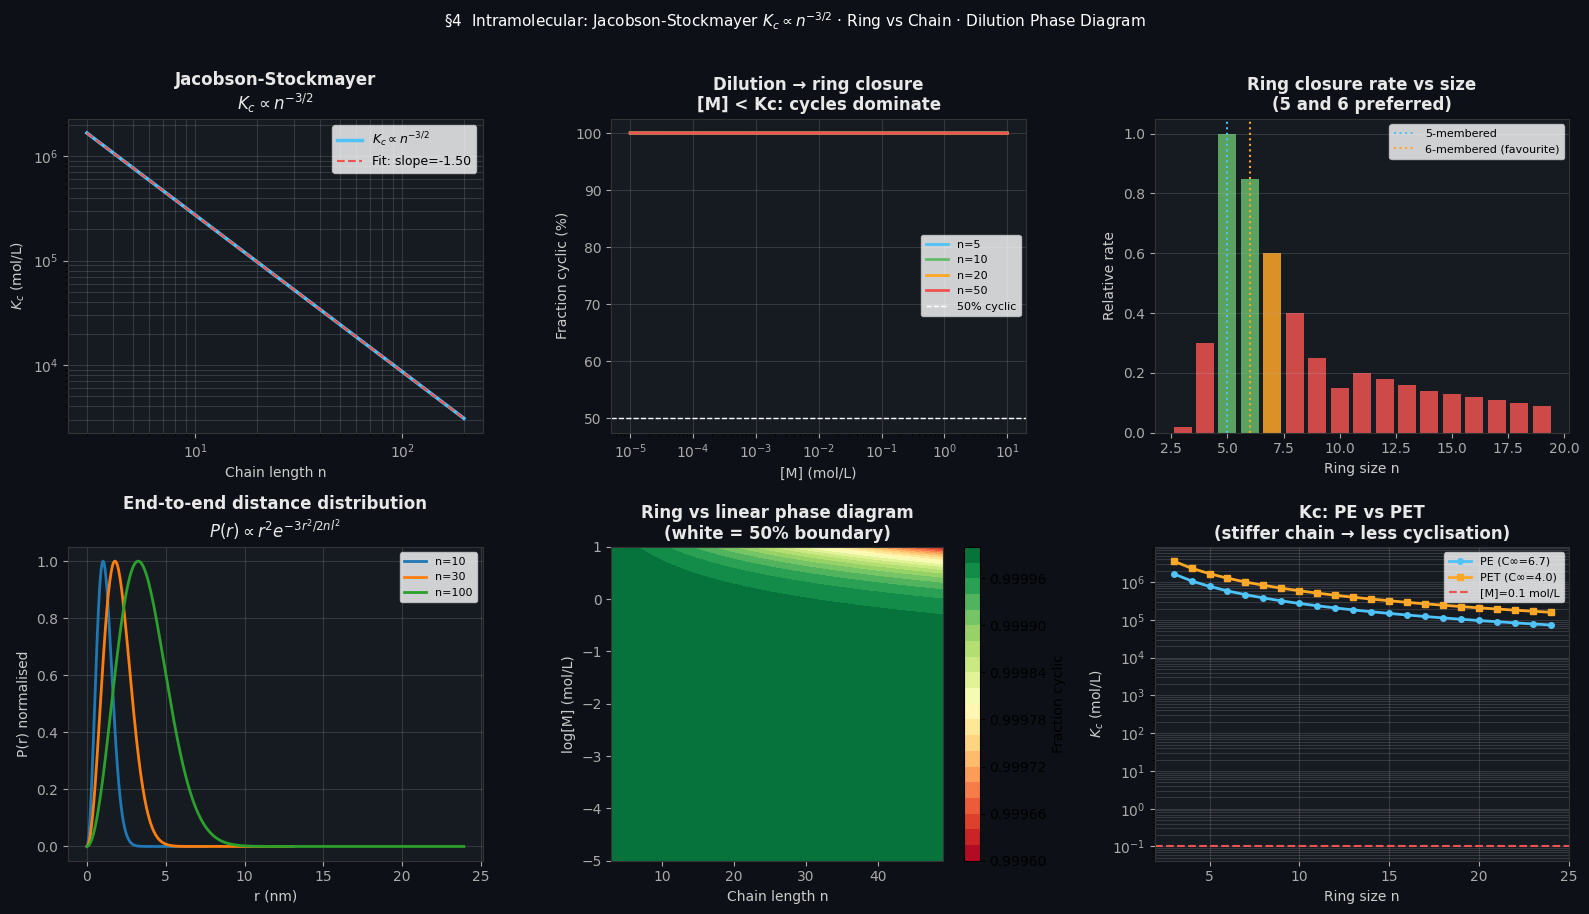


── POLYMER CHEAT SHEET ──────────────────────────────────────────────────
  Flory PDI → 2 (step-growth)  |  Living PDI = 1+1/DP
  Mn_step = M0/(1-p)  diverges at p→1  |  Mn_living grows linearly
  Kc ∝ n^(-3/2)  :  long chains rarely cyclise
  Ring wins when [M] < Kc  :  dilute = cycles, concentrated = linear
  5- and 6-membered rings kinetically/thermodynamically preferred


In [4]:
from scipy.constants import N_A

# ── Jacobson-Stockmayer: Kc vs chain length ────────────────────────────────────
l_bond   = 1.54e-10   # C-C bond length (m)
C_inf    = 6.7        # characteristic ratio for polyethylene
l_eff    = l_bond * np.sqrt(C_inf)   # effective bond length

n_chain_JS = np.arange(3, 200)
r2_0    = n_chain_JS * l_eff**2    # mean-square end-to-end distance (m²)
Kc_SI   = (3/(2*np.pi*r2_0))**1.5 / N_A   # mol/L (converted below)
Kc_molL = Kc_SI * 1e3   # mol/L

print("Jacobson-Stockmayer Kc (cyclisation equilibrium):")
for n, Kc in zip([3,5,8,12,20,50,100], Kc_molL[[0,2,5,9,17,47,97]]):
    print(f"  n={n:3d}: Kc = {Kc:.3e} mol/L  EM ≈ {Kc:.2e}")

# ── Ring vs linear competition ────────────────────────────────────────────────
# Rate of ring closure: k_ring * [chain_end_A] (intramolecular, first order effectively)
# Rate of chain growth: k_inter * [chain_end_A] * [monomer]
# Ring wins when: k_ring > k_inter * [M]  → [M] < Kc (effective molarity)

k_inter_rel = 1.0   # relative intermolecular rate constant
M_concs = [1e-4, 1e-3, 0.01, 0.1, 1.0]   # mol/L

print("\nRing vs chain: winner at each [M] for n=12 (Kc={:.2e})".format(Kc_molL[9]))
Kc_12 = Kc_molL[9]
for M_conc in M_concs:
    ring_rate  = Kc_12
    chain_rate = k_inter_rel * M_conc
    winner = 'RING' if ring_rate > chain_rate else 'chain'
    print(f"  [M]={M_conc:.0e} mol/L: ring rate={ring_rate:.2e}  chain rate={chain_rate:.2e}  -> {winner}")

# ── Dilution effect: fraction cyclic at equilibrium ───────────────────────────
M_range_log = np.logspace(-5, 1, 200)
frac_cyclic_n = {}
for n_ring in [5, 10, 20, 50]:
    idx = n_ring - 3
    Kc_n = Kc_molL[idx] if idx < len(Kc_molL) else Kc_molL[-1]
    # Fraction cyclic = Kc/(Kc + [M])
    frac_cyclic_n[n_ring] = Kc_n / (Kc_n + M_range_log)

# ── Ring size preference: strain energy ───────────────────────────────────────
# Baeyer strain + Pitzer strain:
# 3-membered: very strained, 5 and 6: least strained, >8: strain drops
n_ring_sizes = np.arange(3, 20)
# Empirical ring closure probability (relative, normalized at n=6)
ring_prefs = np.array([0.02, 0.3, 1.0, 0.85, 0.6, 0.4, 0.25, 0.15,
                        0.20, 0.18, 0.16, 0.14, 0.13, 0.12, 0.11, 0.10, 0.09])

print("\nRelative ring closure preference (6-membered = 1.0):")
for n_r, pref in zip(n_ring_sizes, ring_prefs):
    bar = '#' * int(pref*30)
    print(f"  n={n_r:2d}: {pref:.2f} {bar}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig4, axes4 = plt.subplots(2, 3, figsize=(16, 9), facecolor='#0d1117')
for ax in axes4.flat: ax.set_facecolor('#161b22')

ax = axes4[0,0]
ax.loglog(n_chain_JS, Kc_molL, '#4fc3f7', lw=2.5, label=r'$K_c \propto n^{-3/2}$')
slope_fit = np.polyfit(np.log(n_chain_JS), np.log(Kc_molL), 1)
ax.loglog(n_chain_JS, np.exp(slope_fit[1])*n_chain_JS**slope_fit[0],
          '#ef5350', lw=1.5, ls='--', label=f'Fit: slope={slope_fit[0]:.2f}')
ax.set_xlabel('Chain length n'); ax.set_ylabel('$K_c$ (mol/L)')
ax.set_title('Jacobson-Stockmayer\n$K_c\\propto n^{-3/2}$', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.2, which='both')

ax = axes4[0,1]
cols_n = ['#4fc3f7','#66bb6a','#ffa726','#ef5350']
for (n_ring, frac_c), col in zip(frac_cyclic_n.items(), cols_n):
    ax.semilogx(M_range_log, frac_c*100, color=col, lw=2, label=f'n={n_ring}')
ax.axhline(50, color='white', ls='--', lw=1, label='50% cyclic')
ax.set_xlabel('[M] (mol/L)'); ax.set_ylabel('Fraction cyclic (%)')
ax.set_title('Dilution → ring closure\n[M] < Kc: cycles dominate', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

ax = axes4[0,2]
ax.bar(n_ring_sizes, ring_prefs,
       color=['#ef5350' if r<0.5 else '#66bb6a' if r>0.8 else '#ffa726' for r in ring_prefs],
       alpha=0.85)
ax.axvline(5, color='#4fc3f7', ls=':', lw=1.5, label='5-membered')
ax.axvline(6, color='#ffa726', ls=':', lw=1.5, label='6-membered (favourite)')
ax.set_xlabel('Ring size n'); ax.set_ylabel('Relative rate')
ax.set_title('Ring closure rate vs size\n(5 and 6 preferred)', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2, axis='y')

# r^2 distribution for flexible chain
ax = axes4[1,0]
for n_seg in [10, 30, 100]:
    r2_mean = n_seg * l_eff**2
    r_vals  = np.linspace(0, 6*np.sqrt(r2_mean), 300)
    b2      = 3/(2*r2_mean)
    P_r     = 4*np.pi*r_vals**2 * (b2/np.pi)**1.5 * np.exp(-b2*r_vals**2)
    ax.plot(r_vals*1e9, P_r/P_r.max(), lw=2, label=f'n={n_seg}')
ax.set_xlabel('r (nm)'); ax.set_ylabel('P(r) normalised')
ax.set_title('End-to-end distance distribution\n$P(r)\\propto r^2 e^{-3r^2/2nl^2}$',
             color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

# Effective molarity map
ax = axes4[1,1]
n_2d  = np.arange(3, 50)
M_2d  = np.logspace(-5, 1, 100)
N2, M2= np.meshgrid(n_2d, M_2d)
idx_2d = np.clip(N2-3, 0, len(Kc_molL)-1).astype(int)
Kc_2d = Kc_molL[idx_2d]
frac_2d = Kc_2d / (Kc_2d + M2)
cf = ax.contourf(n_2d, np.log10(M_2d), frac_2d,
                  levels=20, cmap='RdYlGn')
plt.colorbar(cf, ax=ax, label='Fraction cyclic')
ax.contour(n_2d, np.log10(M_2d), frac_2d, levels=[0.5], colors='white', linewidths=2)
ax.set_xlabel('Chain length n'); ax.set_ylabel('log[M] (mol/L)')
ax.set_title('Ring vs linear phase diagram\n(white = 50% boundary)', color='#e8e8e8', fontweight='bold')

ax = axes4[1,2]
# Compare PE vs PET ring propensity
n_short = np.arange(3, 25)
Kc_PE  = Kc_molL[:len(n_short)]
# PET has stiffer chain: C_inf ~ 4 vs 6.7 for PE → different l_eff
l_eff_PET = l_bond * np.sqrt(4.0)
r2_PET    = n_short * l_eff_PET**2
Kc_PET    = (3/(2*np.pi*r2_PET))**1.5 / N_A * 1e3
ax.semilogy(n_short, Kc_PE[:len(n_short)], '#4fc3f7', lw=2, marker='o', ms=4, label='PE (C∞=6.7)')
ax.semilogy(n_short, Kc_PET, '#ffa726', lw=2, marker='s', ms=4, label='PET (C∞=4.0)')
ax.axhline(0.1, color='#ef5350', ls='--', lw=1.5, label='[M]=0.1 mol/L')
ax.set_xlabel('Ring size n'); ax.set_ylabel('$K_c$ (mol/L)')
ax.set_title('Kc: PE vs PET\n(stiffer chain → less cyclisation)', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2, which='both')

for ax in axes4.flat:
    ax.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax.spines.values()]
    try: ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')
    except: pass

plt.suptitle(r'§4  Intramolecular: Jacobson-Stockmayer $K_c\propto n^{-3/2}$ · Ring vs Chain · Dilution Phase Diagram',
             color='white', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('/tmp/s4_ring.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("\n── POLYMER CHEAT SHEET ──────────────────────────────────────────────────")
print("  Flory PDI → 2 (step-growth)  |  Living PDI = 1+1/DP")
print("  Mn_step = M0/(1-p)  diverges at p→1  |  Mn_living grows linearly")
print("  Kc ∝ n^(-3/2)  :  long chains rarely cyclise")
print("  Ring wins when [M] < Kc  :  dilute = cycles, concentrated = linear")
print("  5- and 6-membered rings kinetically/thermodynamically preferred")


## Summary

| § | Key result |
|---|---|
|**SVD**| $A=U\Sigma V^T$; best rank-k approx error = $\sigma_{k+1}$ (Eckart-Young) |
|**PCA**| SVD of centered $X/\sqrt{n-1}$; LoRA replaces $\Delta W=AB$, $r\ll d$ |
|**Kinetics**| $k=Ae^{-E_a/RT}$; stiff MM solved with Radau; radical: $d[P^\bullet]/dt=R_i-k_t[P^\bullet]^2$ |
|**Polymer**| Flory PDI→2; living PDI=1+1/DP; step Mn=M0/(1-p), addition Mn grows linearly |
|**Intramolecular**| $K_c\propto n^{-3/2}$; ring wins when $[M]<K_c$; 5- and 6-membered preferred |
